In [4]:
from tensorflow.keras.models import load_model

# Load the weights from the saved model
model = load_model('../models/my_model.keras')


c:\Users\zgibio\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 60 variables whereas the saved optimizer has 122 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


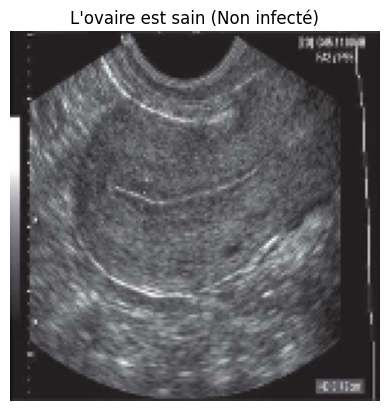

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


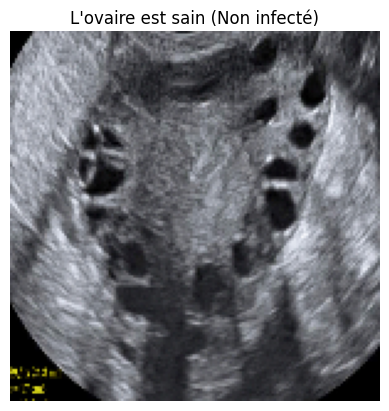

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


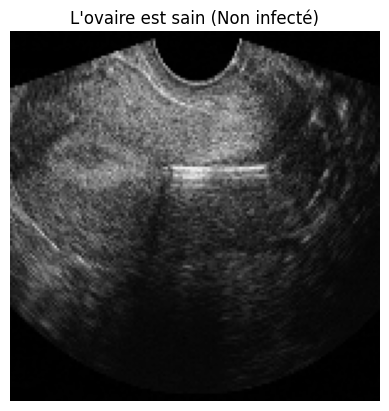

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


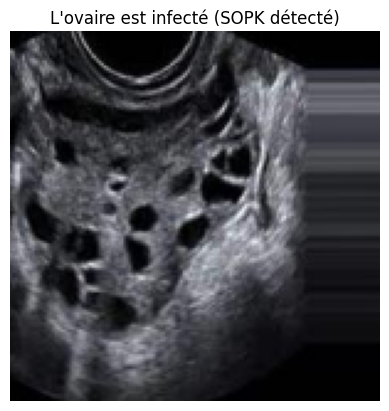

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


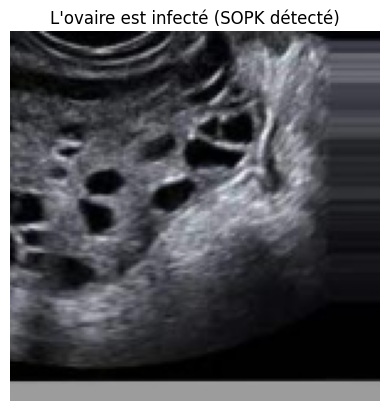

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


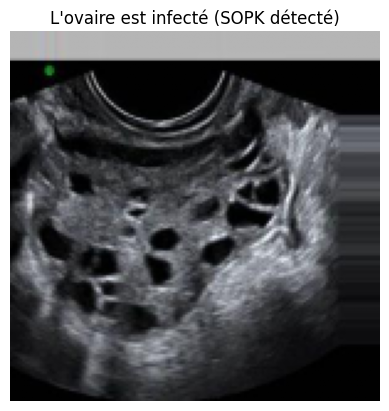

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


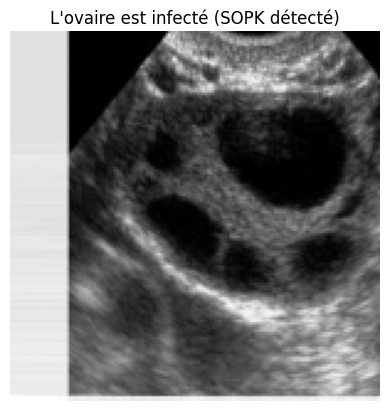

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


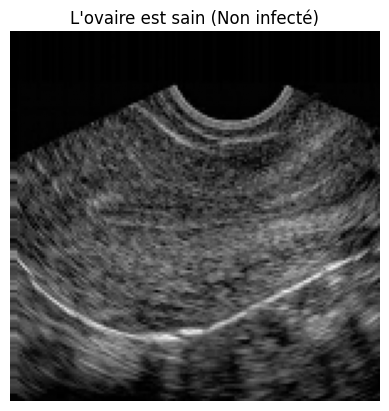

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


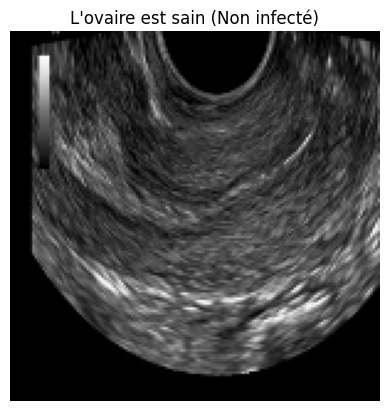

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


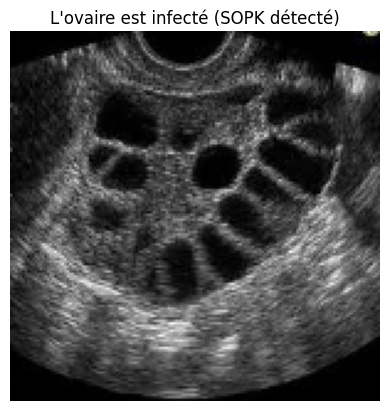

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


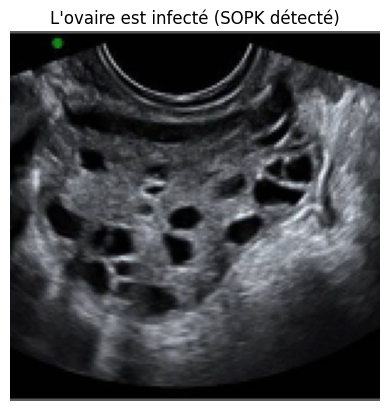

In [7]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model



# Chemin des images de test
test_images_dir = r"C:\Users\zgibio\Desktop\platform_sopk\Plateforme SOPK\Datasets\dataeco"


# Lister toutes les images du dossier
test_images = [f for f in os.listdir(test_images_dir) if f.endswith(('jpg', 'jpeg', 'png', 'jfif'))]

# Fonction de prétraitement des images
def preprocess_image(image_path):
    # Lire l'image
    image = cv2.imread(image_path)

    # Vérifier si l'image est bien chargée
    if image is None:
        print(f"Erreur lors du chargement de l'image {image_path}.")
        return None

    # Convertir l'image de BGR à RGB (OpenCV charge en BGR par défaut)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Redimensionner l'image à 150x150 (taille du modèle CNN)
    image_resized = cv2.resize(image_rgb, (150, 150))

    # Normaliser les pixels entre [0, 1]
    image_normalized = image_resized / 255.0

    # Remodeler l'image pour correspondre à l'entrée du modèle (batch_size, hauteur, largeur, canaux)
    image_reshaped = image_normalized.reshape(1, 150, 150, 3)

    return image_reshaped

# Parcourir toutes les images du dossier
for img_name in test_images:
    img_path = os.path.join(test_images_dir, img_name)
    # Prétraiter l'image
    image_reshaped = preprocess_image(img_path)

    # Si l'image n'a pas pu être prétraitée correctement, ignorer
    if image_reshaped is None:
        continue

    # Faire une prédiction
    prediction = model.predict(image_reshaped)

    # Déterminer le résultat
    if prediction[0][0] > 0.5:
        result = "L'ovaire est sain (Non infecté)"
    else:
        result = "L'ovaire est infecté (SOPK détecté)"

    # Afficher l'image avec le résultat de la prédiction
    plt.imshow(image_reshaped[0])  # Reshaped image already has 1 batch
    plt.title(result)
    plt.axis('off')  # Cacher les axes pour une meilleure lisibilité
    plt.show()
